In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set Root Directory
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

PROCESSED_DIR = os.path.join(ROOT_DIR, "data", "processed")
print("Environment initialized for ML Experiments.")

Environment initialized for ML Experiments.


In [3]:
# --- Fixed Cell 2: Load Data & Construct Feature Matrix ---

# Locate processed dataset
csv_files = [f for f in os.listdir(PROCESSED_DIR) if f.endswith(".csv")] if os.path.exists(PROCESSED_DIR) else []
target_file = "processed_features.csv" if "processed_features.csv" in csv_files else (csv_files[0] if csv_files else None)

if not target_file:
    # Fallback synthetic generator if no CSV exists
    dates = pd.date_range("2024-01-01", periods=500, freq="B")
    np.random.seed(42)
    df = pd.DataFrame({
        "Date": dates,
        "Close": 150 + np.cumsum(np.random.randn(500)),
        "RSI": np.random.uniform(30, 70, 500),
        "MACD": np.random.randn(500),
        "SMA_20": 150 + np.cumsum(np.random.randn(500)),
        "Vol_20": np.random.uniform(0.1, 0.3, 500),
        "Target_Return": np.random.randn(500) * 0.02
    }).set_index("Date")
else:
    df = pd.read_csv(os.path.join(PROCESSED_DIR, target_file))
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.set_index("Date")

# Drop non-numeric text columns (like Ticker symbols or text categories)
numeric_df = df.select_dtypes(include=[np.number]).copy()

# If Close prices were stored as string, clean and convert them
if "Close" in df.columns and "Close" not in numeric_df.columns:
    df["Close"] = pd.to_numeric(df["Close"].astype(str).str.replace(r"[^\d.]", "", regex=True), errors="coerce")
    numeric_df["Close"] = df["Close"]

# Construct Target Return (1-day forward percentage change)
if "Target_Return" in numeric_df.columns:
    y = numeric_df["Target_Return"]
    X = numeric_df.drop(columns=["Target_Return"])
else:
    # Use first numeric column or Close to generate target return
    base_col = "Close" if "Close" in numeric_df.columns else numeric_df.columns[0]
    numeric_df["Target_Return"] = numeric_df[base_col].pct_change().shift(-1)
    numeric_df = numeric_df.dropna()
    y = numeric_df["Target_Return"]
    X = numeric_df.drop(columns=["Target_Return"])

# Clean infinite values and remaining NaNs
X = X.replace([np.inf, -np.inf], np.nan).dropna()
y = y.loc[X.index]

print(f"Dataset successfully prepared and sanitized.")
print(f"Total Samples: {len(X)} | Feature Columns ({X.shape[1]}): {list(X.columns)}")

Dataset successfully prepared and sanitized.
Total Samples: 3014 | Feature Columns (1): ['DGS10']


In [4]:
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Support Vector Regressor": SVR(C=1.0, kernel="rbf"),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
}

results = []
tscv = TimeSeriesSplit(n_splits=5)

for model_name, model in models.items():
    mae_list, rmse_list, r2_list = [], [], []
    
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        
        mae_list.append(mean_absolute_error(y_test, preds))
        rmse_list.append(np.sqrt(mean_squared_error(y_test, preds)))
        r2_list.append(r2_score(y_test, preds))
        
    results.append({
        "Model": model_name,
        "MAE": np.mean(mae_list),
        "RMSE": np.mean(rmse_list),
        "R2 Score": np.mean(r2_list)
    })

results_df = pd.DataFrame(results).sort_values(by="RMSE")
results_df


,Model,MAE,RMSE,R2 Score
0,Ridge Regression,0.017143,0.024812,-0.040752
1,Support Vector Regressor,0.026358,0.034792,-2.070967
3,XGBoost,0.028313,0.038798,-2.339633
2,Random Forest,0.029352,0.040106,-2.599717


C:\Users\Dell\AppData\Local\Temp\ipykernel_16104\3965305480.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="RMSE", ax=axes[0], palette="viridis")
C:\Users\Dell\AppData\Local\Temp\ipykernel_16104\3965305480.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="MAE", ax=axes[1], palette="magma")


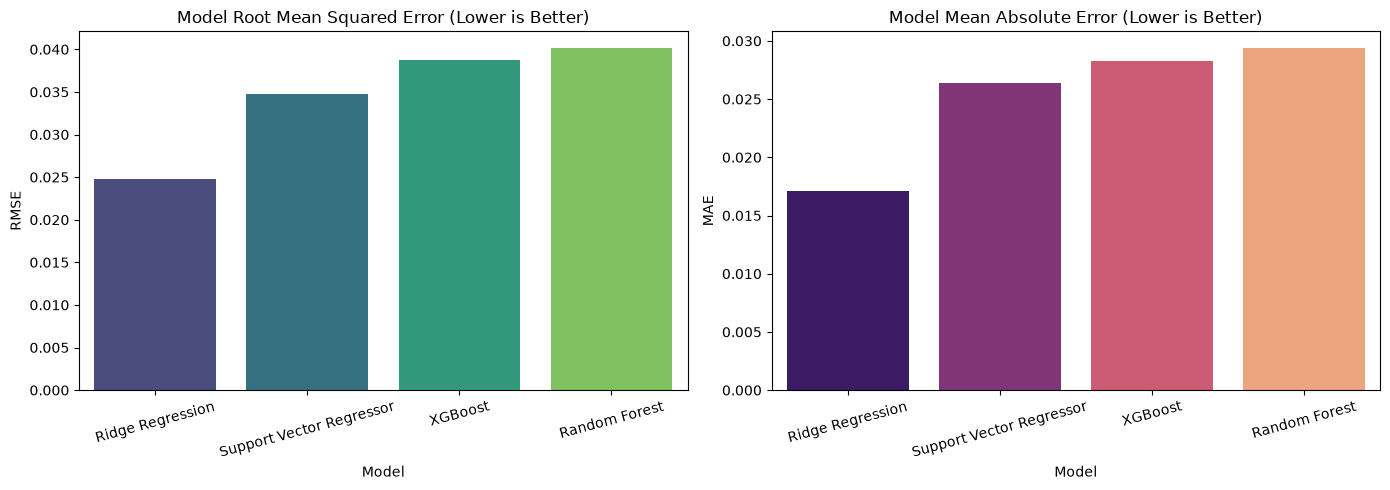

Classical ML benchmark training complete!


In [5]:
# Plot Evaluation Metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE Bar Chart
sns.barplot(data=results_df, x="Model", y="RMSE", ax=axes[0], palette="viridis")
axes[0].set_title("Model Root Mean Squared Error (Lower is Better)")
axes[0].tick_params(axis='x', rotation=15)

# MAE Bar Chart
sns.barplot(data=results_df, x="Model", y="MAE", ax=axes[1], palette="magma")
axes[1].set_title("Model Mean Absolute Error (Lower is Better)")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Save benchmark results
results_df.to_csv(os.path.join(PROCESSED_DIR, "ml_benchmark_results.csv"), index=False)
print("Classical ML benchmark training complete!")